In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

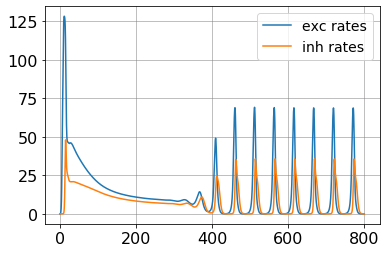

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

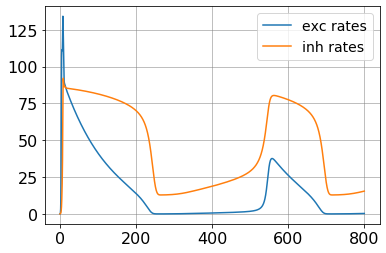

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

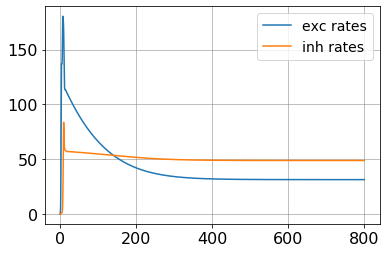

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

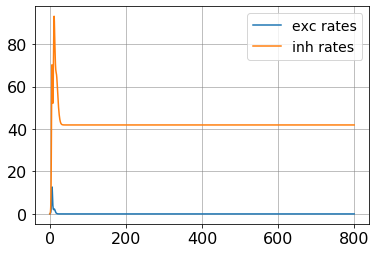

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

In [8]:
def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
    elif cntrl_vars == [1]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [2]:
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
            
    return max_cntrl, min_cntrl     

def findclosestindex(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate)):
        diff = np.abs(osc_rate[t] - stable_rate)
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind
        
    
def findclosestindex_2d(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate[0,:])):
        diff = np.abs(osc_rate[0,t] - stable_rate[0]) + np.abs(osc_rate[1,t] - stable_rate[1])
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind

def setpredur(prec_vars):
    if prec_vars == [0]:
        dur_pre = dur_pre_e
    elif prec_vars == [1]:
        dur_pre = dur_pre_i
    else:
        dur_pre = dur_pre_2d
    n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
    
    return dur_pre, n_pre

def settarget(initVars_, dur_, dur_pre_, n_pre_):
    aln.params.duration = dur_

    # set low state rates as target
    target = aln.getZeroTarget()
    target[:,0,n_dt_maxDelay:] = target_rates[0]
    target[:,1,n_dt_maxDelay:] = target_rates[1]

    aln.params.duration = dur_ + dur_pre_
    setinit(initVars_)
    aln.run(control=aln.getZeroControl())
    target[:,0,:n_dt_maxDelay] = aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay]
    target[:,1,:n_dt_maxDelay] = aln.rates_inh[0,n_pre_:n_pre_+n_dt_maxDelay]
    
    aln.params.duration = dur_

    #print(aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay])
    
    return target

    #plt.plot(np.arange(0,dur+0.1,0.1), target[0,0,:])

In [9]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50
set_params_fast()
initVars = fast_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

sheet = "C_a_"

target_rates = np.array( [down_rates[0], down_rates[1]])

# 40 timesteps max delay
n_dt_maxDelay = aln.getMaxDelay()


In [10]:
dur = 150

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()

aln.run(control=control0)
mindiff_e, minind_e = findclosestindex(aln.rates_exc[0,:], target_rates[0], 250)
print(mindiff_e, minind_e)
dur_pre_e = ( minind_e - n_dt_maxDelay ) / 10.
print(dur_pre_e)

mindiff_i, minind_i = findclosestindex(aln.rates_inh[0,:], target_rates[1], 250)
print(mindiff_i, minind_i)
dur_pre_i = ( minind_i - n_dt_maxDelay ) / 10.
print(dur_pre_i)

findclosestindex_2d
mindiff_2d, minind_2d = findclosestindex_2d(np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] ),
                                            target_rates, 250)
print(mindiff_2d, minind_2d)
dur_pre_2d = ( minind_2d - n_dt_maxDelay ) / 10.
print(dur_pre_2d)

0.04374523811346089 993
95.3
6.295188628552943 1289
124.9
26.06851836556112 1344
130.4


## 0

set cost params
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  0.00017932956436493558
RUN  1 , total integrated cost =  0.00016413190272425383
RUN  2 , total integrated cost =  0.00016413190272425337
RUN  3 , total integrated cost =  0.00016413190272425313
RUN  4 , total integrated cost =  0.00016413190272425237


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  0.00016413190272425237
Control only changes marginally.
RUN  5 , total integrated cost =  0.00016413190272425237
Improved over  5  iterations by  8.474710622592028  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716


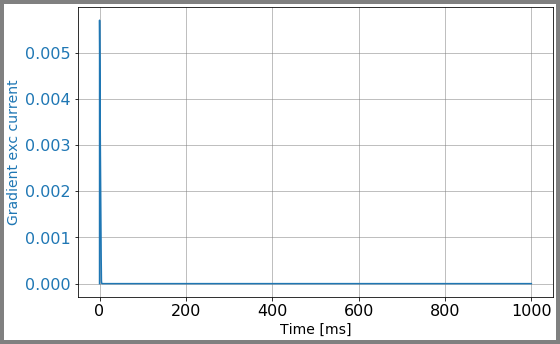

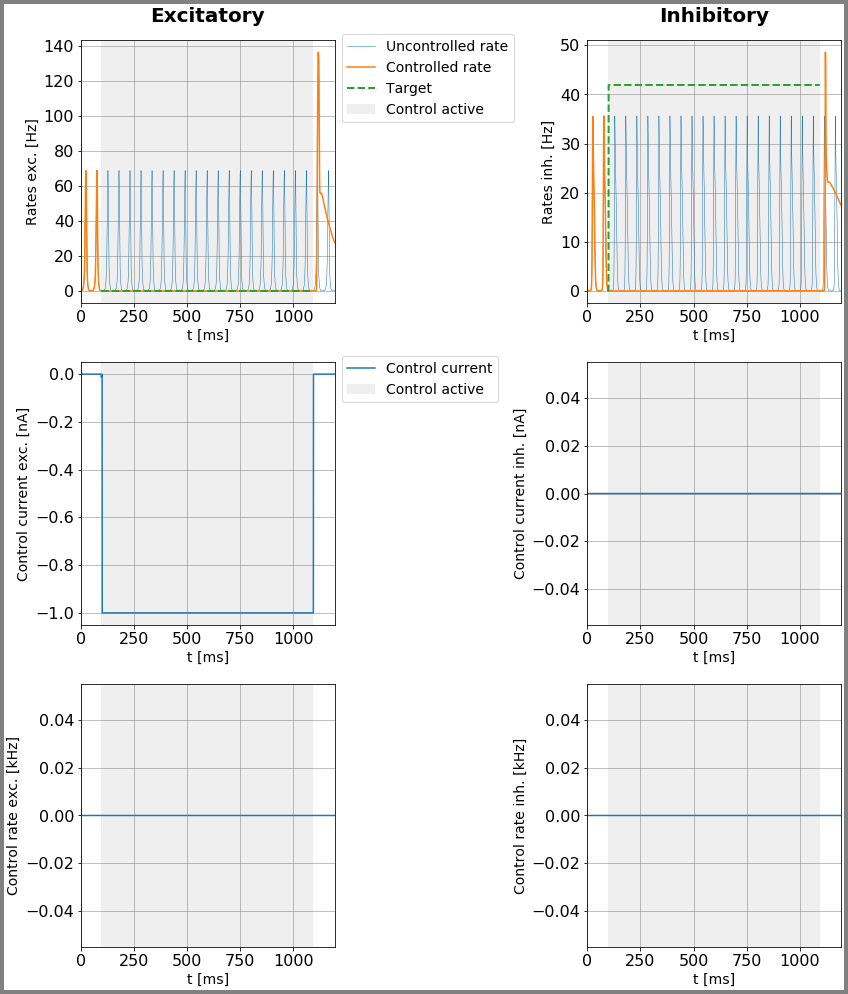

In [11]:
# C.0.a)

dur = 1000
dur_post = 100
n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

dur_pre, n_pre = setpredur(prec_vars)

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()

#control1 = bestControla[:,:,n_pre-1:-n_post+1]
control0[0,0,n_dt_maxDelay:] = -5.

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  374010.9159585342
RUN  1 , total integrated cost =  206566.40853514848
RUN  2 , total integrated cost =  78027.30417292415
RUN  3 , total integrated cost =  75115.98108114673
RUN  4 , total integrated cost =  74815.35167883875


ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  74815.35167883875
Control only changes marginally.
RUN  5 , total integrated cost =  74815.35167883875
Improved over  5  iterations by  79.99647911690006  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716


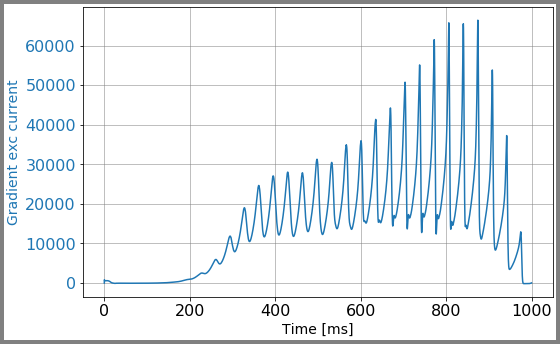

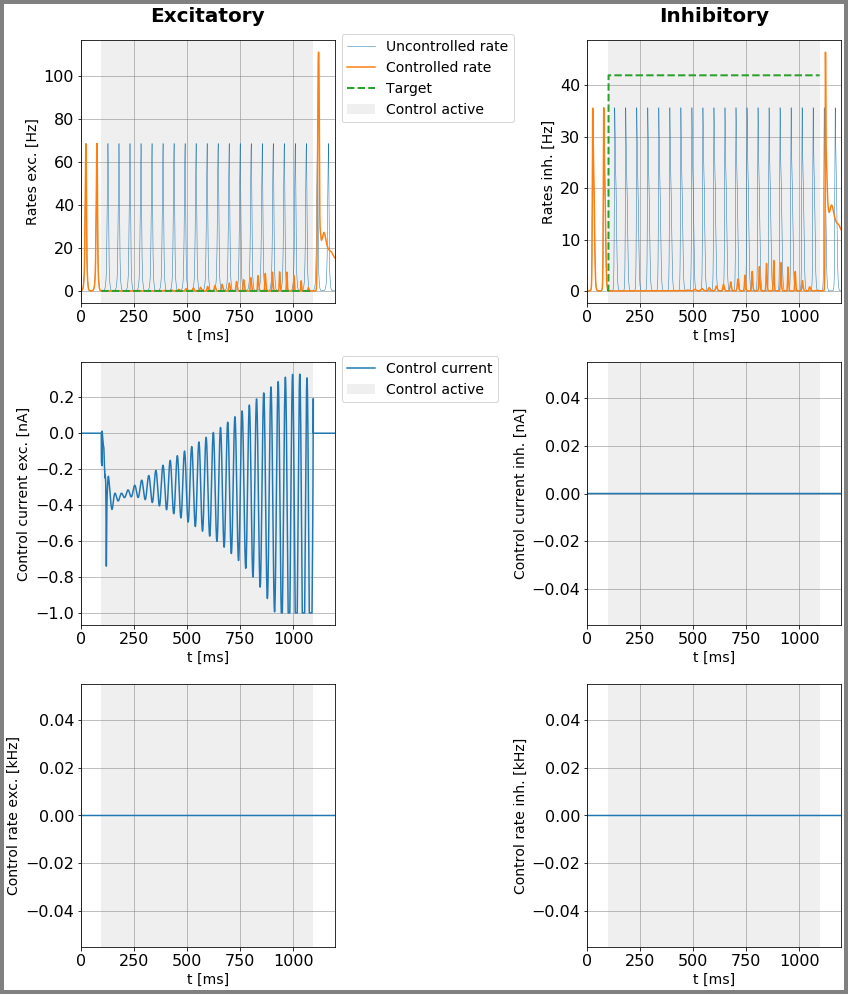

In [12]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -5.
control2 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )


## 2

set cost params
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  258179.3103395276
RUN  1 , total integrated cost =  258147.02073259588
RUN  2 , total integrated cost =  258137.5465213469
RUN  3 , total integrated cost =  258137.25968503952
RUN  4 , total integrated cost =  258137.25968503932
RUN  5 , total integrated cost =  258137.25968503926
RUN  6 , total integrated cost =  258137.25968503908


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  258137.25968503908
Control only changes marginally.
RUN  7 , total integrated cost =  258137.25968503908
Improved over  7  iterations by  0.016287383537132882  percent.
Problem in initial value trasfer:  sigmae_f 1.6389338218294596 1.6388097320965958
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.56334584160552
Problem in initial value trasfer:  tau_exc 18.7743540009113 18.775498900605832
Problem in initial value trasfer:  Vmean_exc -61.30023453852179 -61.255007862444025


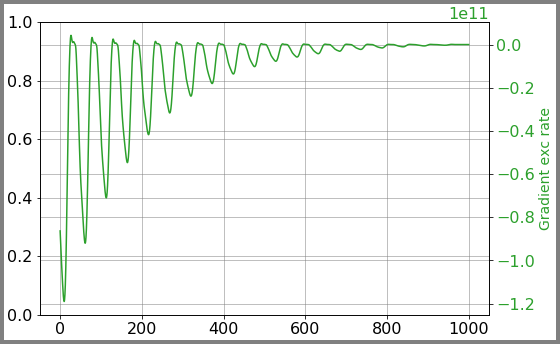

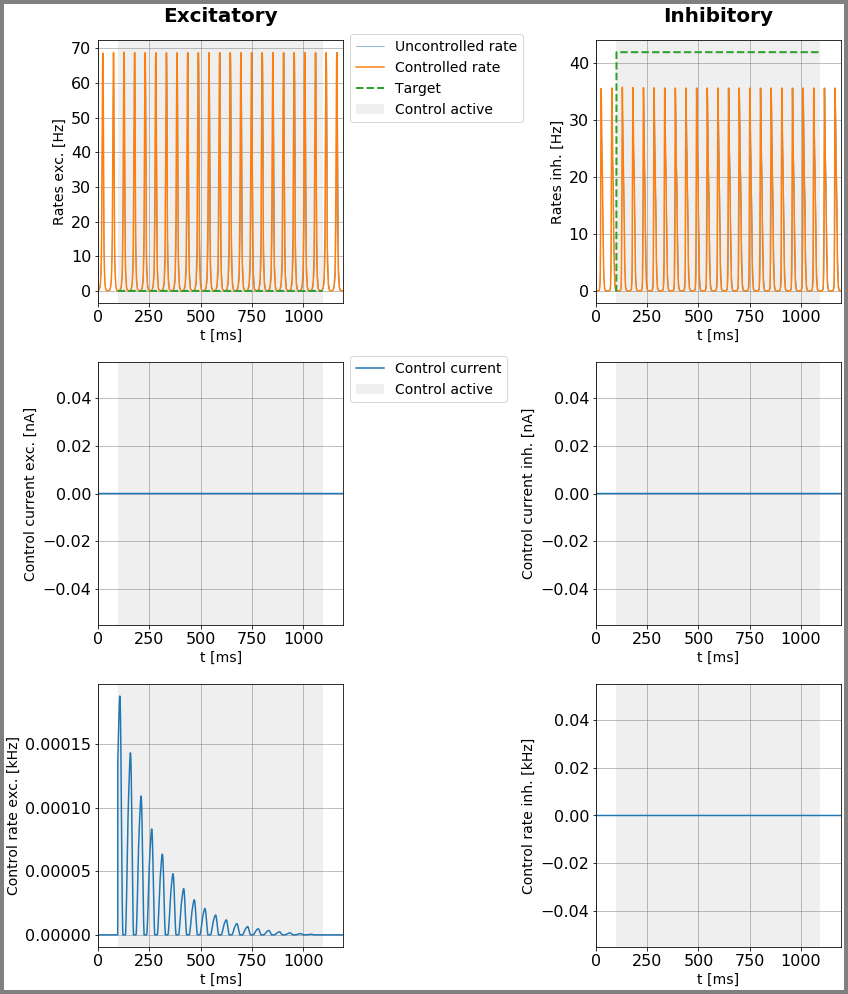

In [15]:
# A.0.a)

case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

max_it = 30

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl,  t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

# 67940

set cost params
RUN  0 , total integrated cost =  258137.26311387942


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  258137.26311387942
Control only changes marginally.
RUN  1 , total integrated cost =  258137.26311387942
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.6389338218294596 1.6388097320965958
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.56334584160552
Problem in initial value trasfer:  tau_exc 18.7743540009113 18.775498900605832
Problem in initial value trasfer:  Vmean_exc -61.30023453852179 -61.255007862444025


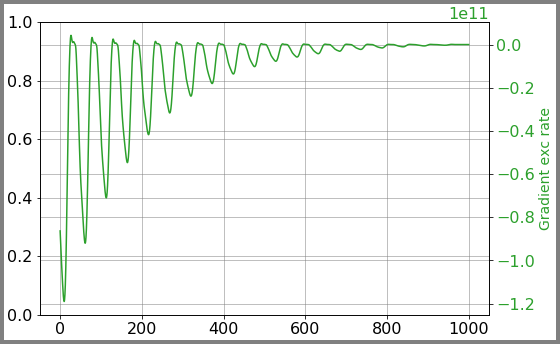

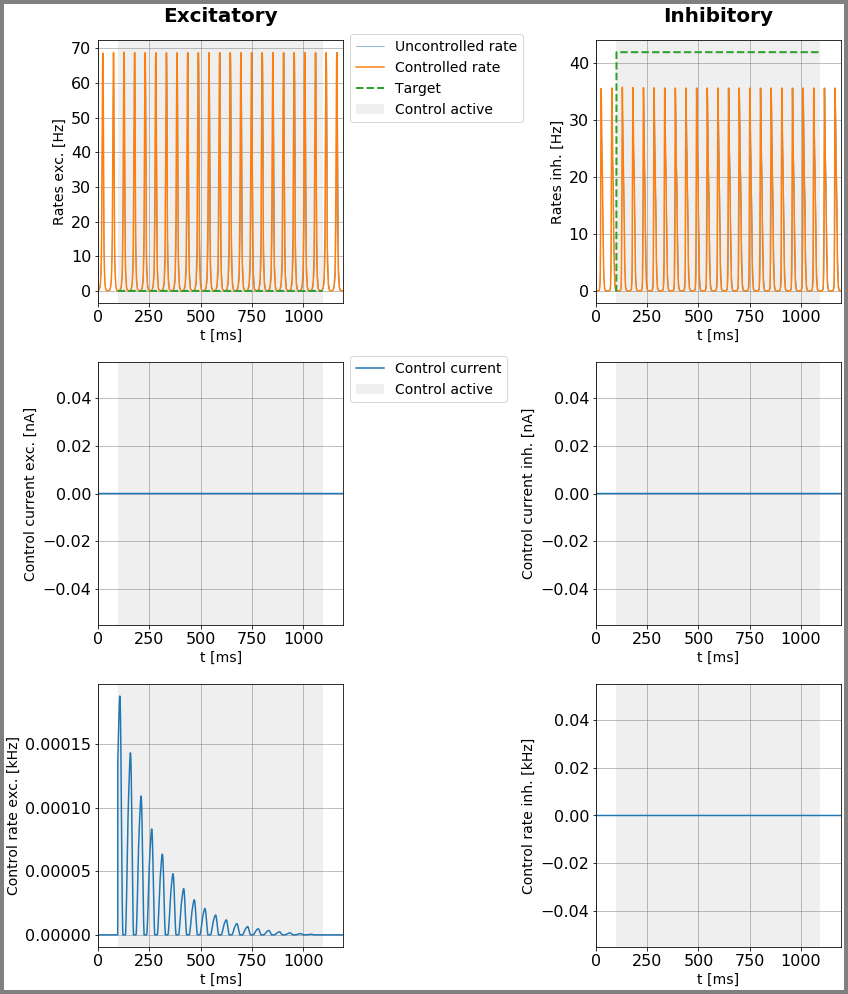

In [16]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
ontrol0 = aln.getZeroControl()
#control0[0,2,:] = 0.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 4

set cost params
control input:  [1] , precision measure:  [0]
RUN  0 , total integrated cost =  0.0007874409961589294


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.0007874409961589294
Control only changes marginally.
RUN  1 , total integrated cost =  0.0007874409961589294
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716
Problem in initial value trasfer:  Vmean_exc -78.77175490269993 -78.77175443021112


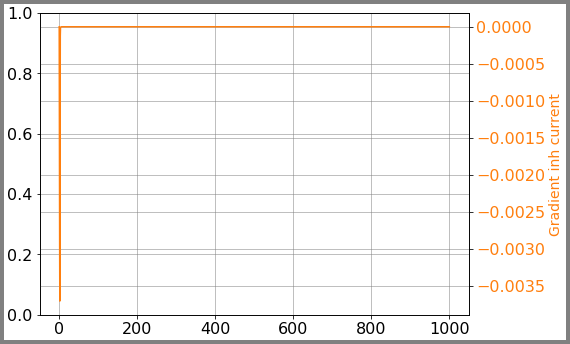

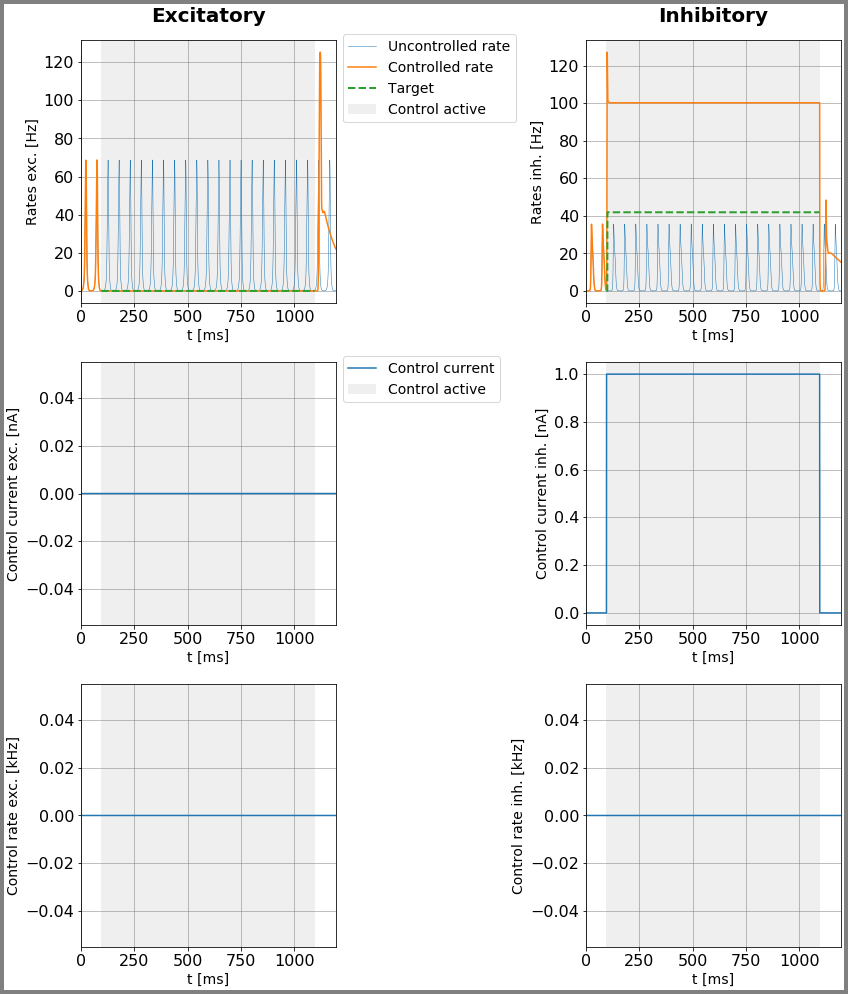

In [19]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  375511.8661529558
RUN  1 , total integrated cost =  314203.53731813445
RUN  2 , total integrated cost =  64960.478158026475
RUN  3 , total integrated cost =  64960.47815802646


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  64960.47815802646
Control only changes marginally.
RUN  4 , total integrated cost =  64960.47815802646
Improved over  4  iterations by  82.70081879874168  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716
Problem in initial value trasfer:  Vmean_exc -76.11727563474743 -76.00843410683376


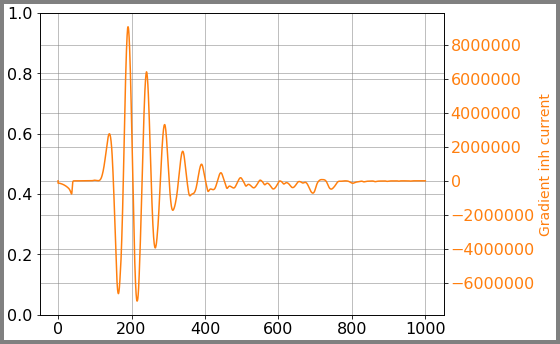

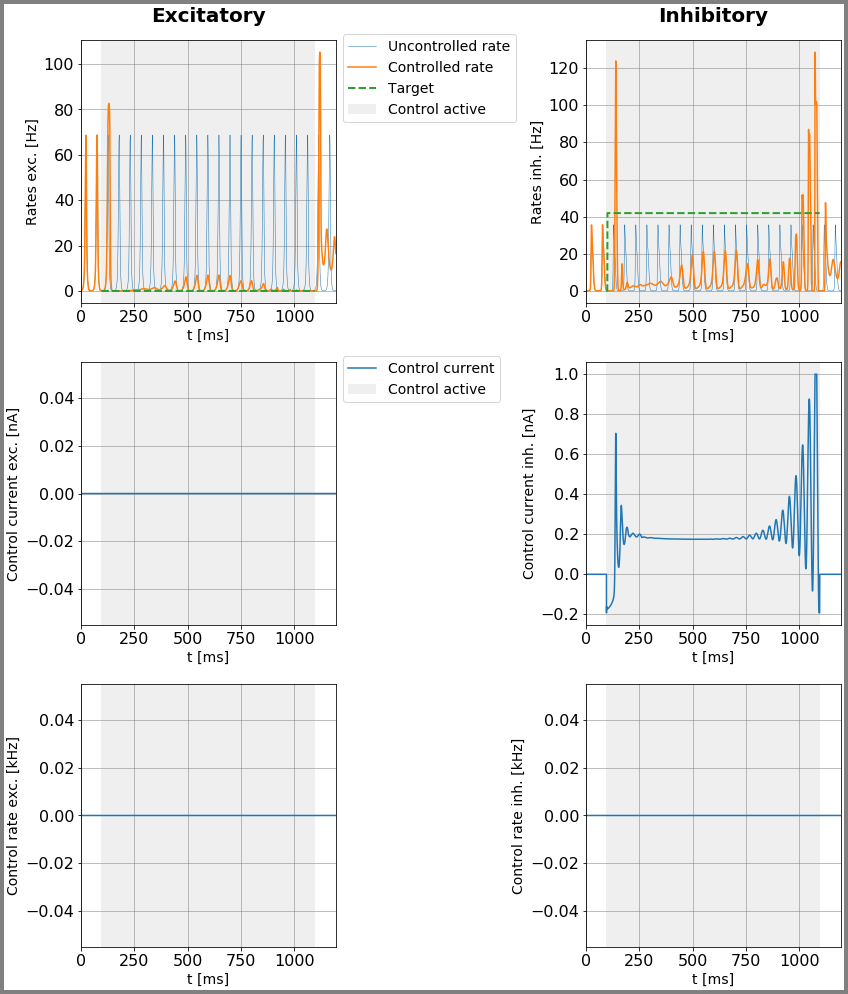

In [20]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
RUN  0 , total integrated cost =  0.0033356776669938816
RUN  1 , total integrated cost =  0.000713734333930917
RUN  2 , total integrated cost =  0.0007072722974787576
RUN  3 , total integrated cost =  0.0007072335404347499
RUN  4 , total integrated cost =  0.0007072334973814193
RUN  5 , total integrated cost =  0.0007072334973814114
RUN  6 , total integrated cost =  0.0007072334973814098
RUN  7 , total integrated cost =  0.0007072334973814087
RUN  8 , total integrated cost =  0.0007072334973814068
RUN  9 , total integrated cost =  0.0007072334973814048


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  0.0007072334973814048
Control only changes marginally.
RUN  10 , total integrated cost =  0.0007072334973814048
Improved over  10  iterations by  78.79790651298856  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716
Problem in initial value trasfer:  Vmean_exc -80.81144292429484 -80.81144204568345


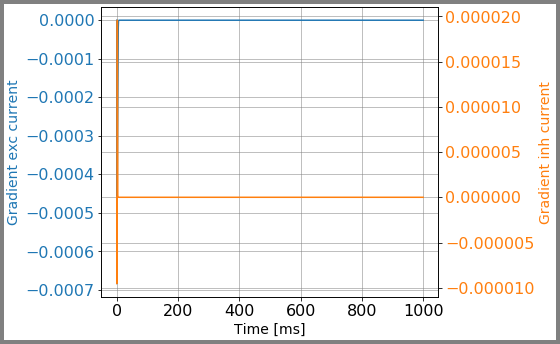

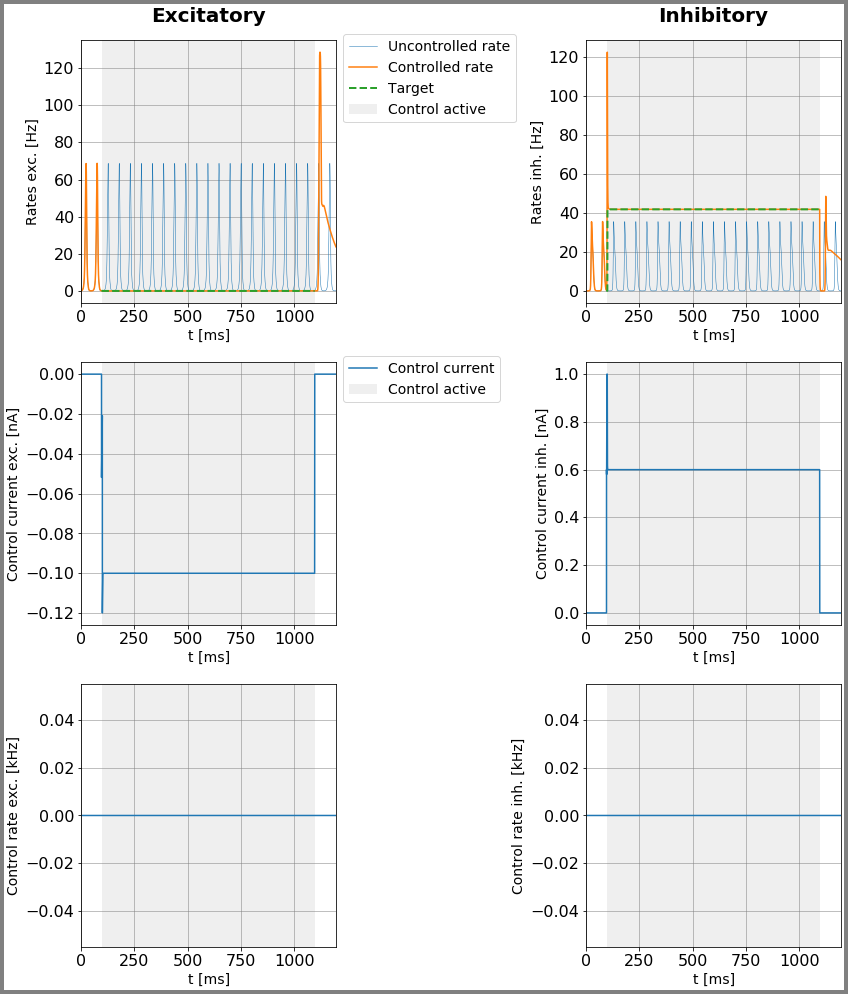

In [23]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -0.5
control0[0,1,:] = 3.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)


bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  139080.83913290701
RUN  1 , total integrated cost =  9214.240631869707
RUN  2 , total integrated cost =  9188.259996755374
RUN  3 , total integrated cost =  9168.083193938219
RUN  4 , total integrated cost =  9149.794722111797
RUN  5 , total integrated cost =  9138.415287214882
RUN  6 , total integrated cost =  9135.80860652128


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  9135.80860652128
Control only changes marginally.
RUN  7 , total integrated cost =  9135.80860652128
Improved over  7  iterations by  93.43129602648499  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716
Problem in initial value trasfer:  Vmean_exc -59.36625355871044 -59.36421708554592


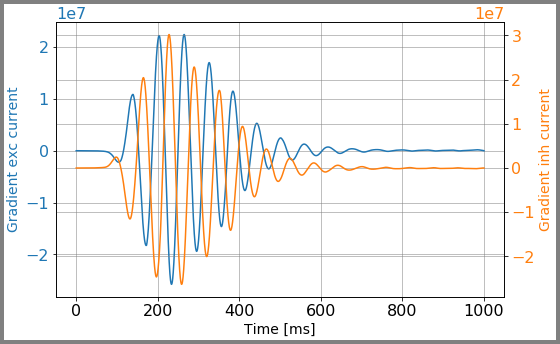

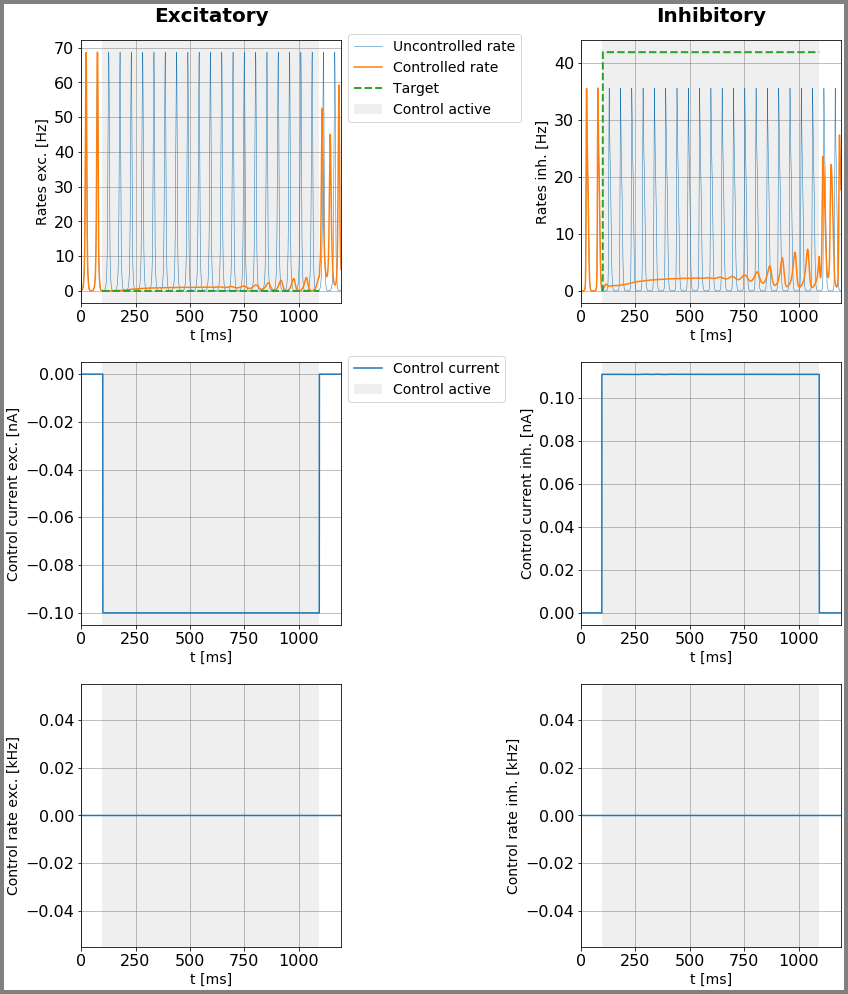

In [24]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -0.5
control0[0,1,:] = 3.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

#3813.6338429321895

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  0.004147343757059339
RUN  1 , total integrated cost =  0.0028581110417207167
RUN  2 , total integrated cost =  0.002811162173095933
RUN  3 , total integrated cost =  0.0028109906794401927
RUN  4 , total integrated cost =  0.002810936630685663
RUN  5 , total integrated cost =  0.0028109356278239565
RUN  6 , total integrated cost =  0.002810935627535527
RUN  7 , total integrated cost =  0.0028109356275355228


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  0.0028109356275355228
Control only changes marginally.
RUN  8 , total integrated cost =  0.0028109356275355228
Improved over  8  iterations by  32.22323028442166  percent.
Problem in initial value trasfer:  sigmae_f 1.6389338218294596 1.6234277714612955
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.56109912557739
Problem in initial value trasfer:  tau_exc 18.7743540009113 18.91741879700826


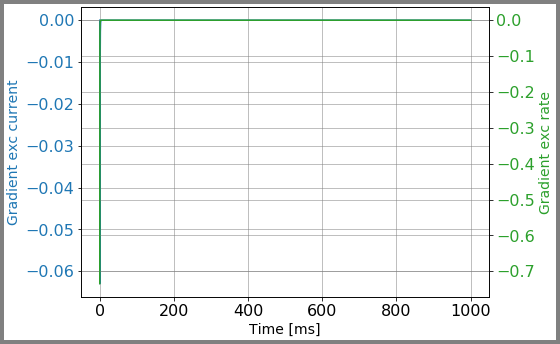

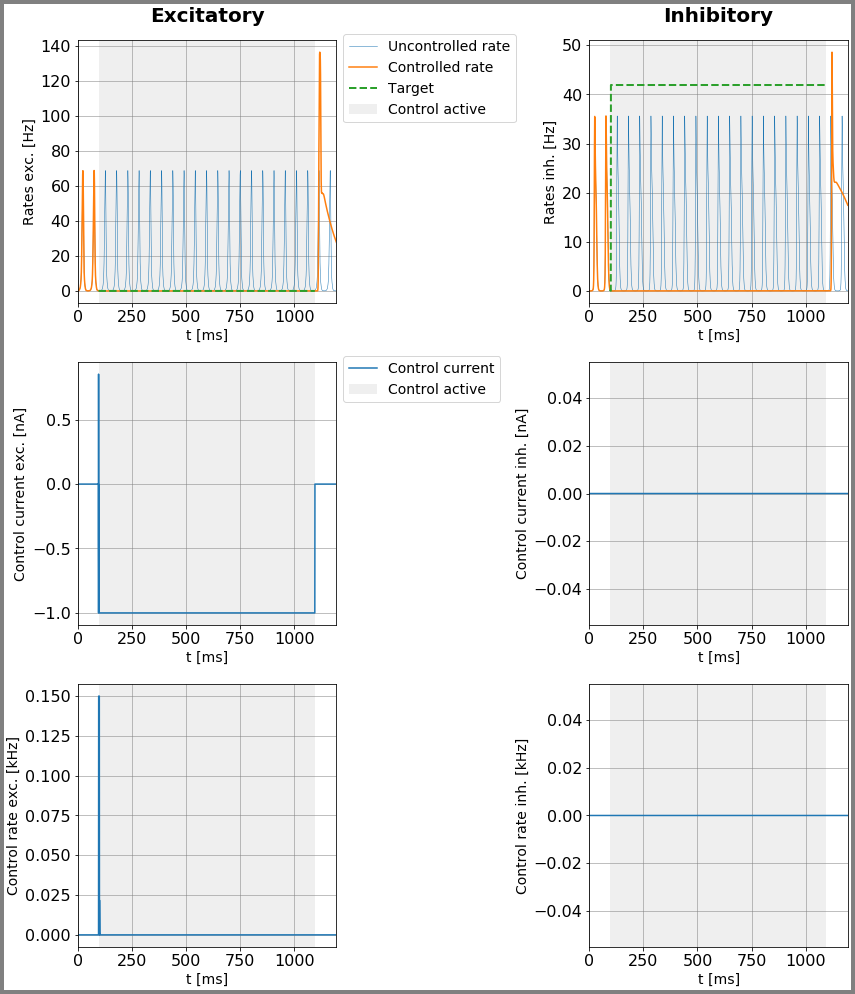

In [27]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  375308.75961668475
RUN  1 , total integrated cost =  205517.24330298553
RUN  2 , total integrated cost =  77872.04629707868
RUN  3 , total integrated cost =  74944.60882876109
RUN  4 , total integrated cost =  74944.60882876106
RUN  5 , total integrated cost =  74944.60882876068


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  74944.60882876068
Control only changes marginally.
RUN  6 , total integrated cost =  74944.60882876068
Improved over  6  iterations by  80.03121245949492  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716


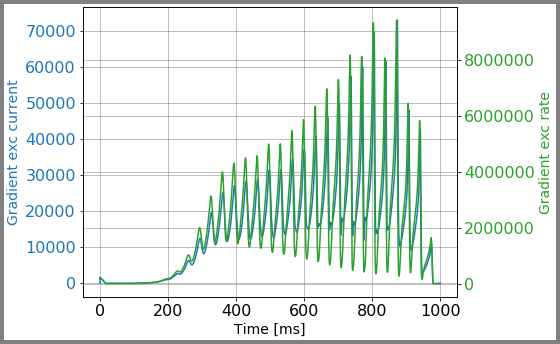

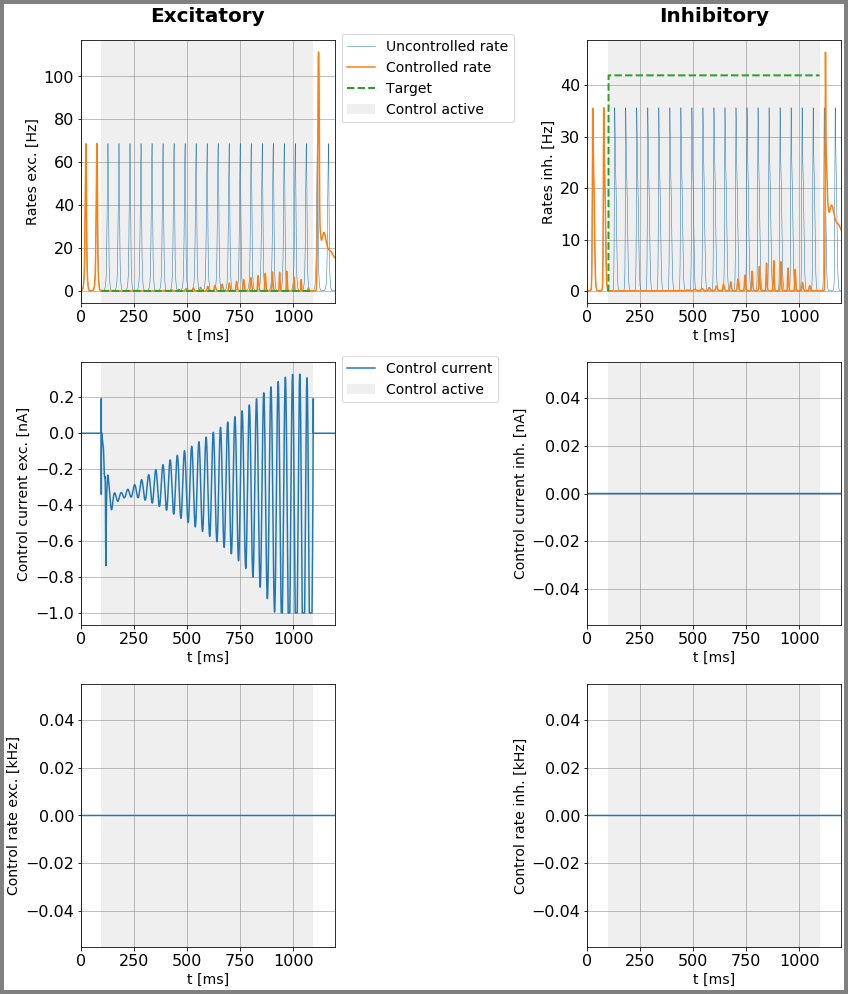

In [28]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = -5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

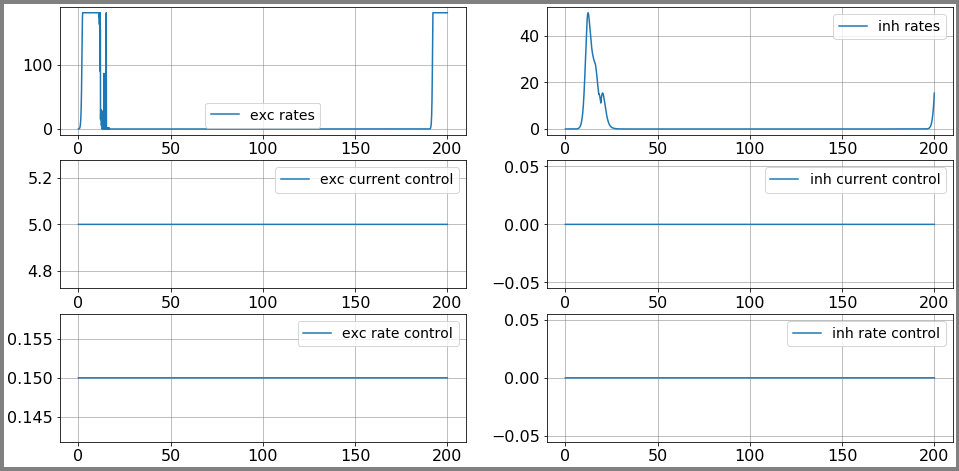

In [29]:
aln.params.duration = 200
con = aln.getZeroControl()
con[0,0,:] = 5.
con[0,2,:] = 0.15
plotFunc.plot_traces(aln, con)

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  0.0007874409961589294


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.0007874409961589294
Control only changes marginally.
RUN  1 , total integrated cost =  0.0007874409961589294
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716
Problem in initial value trasfer:  Vmean_exc -78.77175490269993 -78.77175443021112


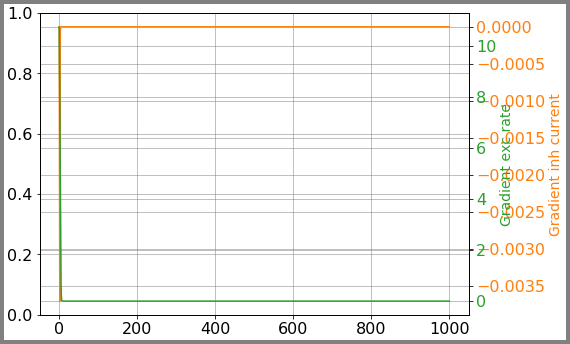

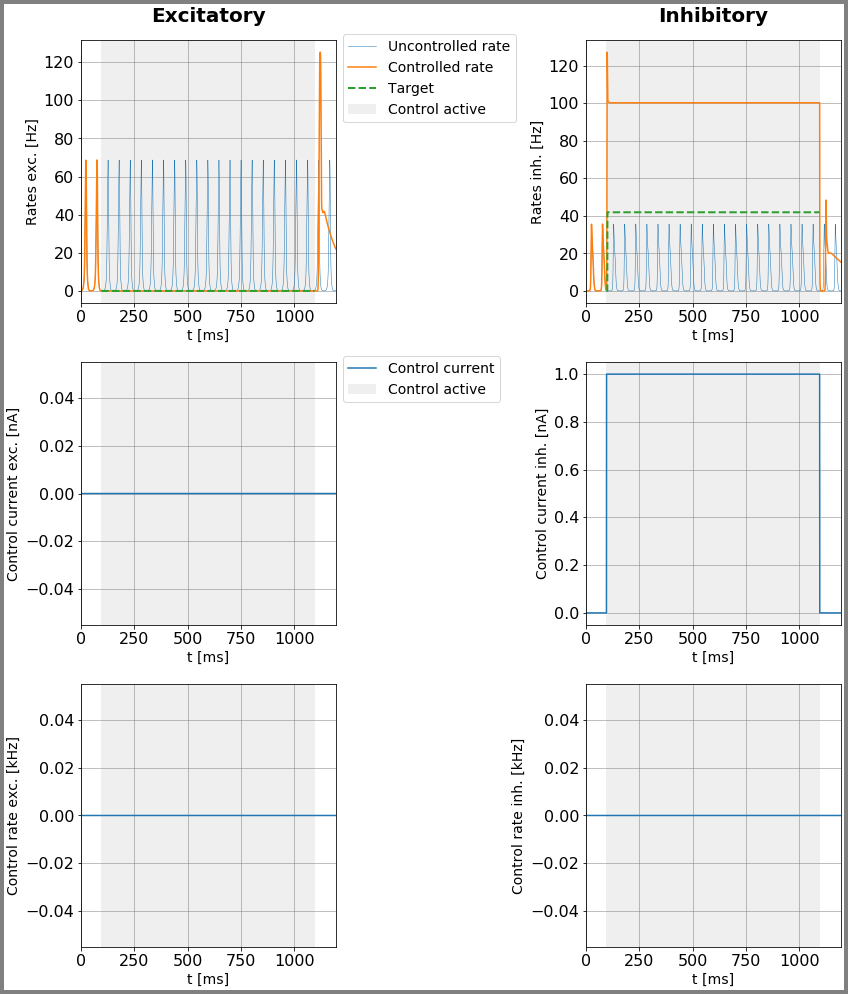

In [32]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  21361.957354132282
RUN  1 , total integrated cost =  21244.786117589752
RUN  2 , total integrated cost =  21244.786117589727


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  21244.786117589727
Control only changes marginally.
RUN  3 , total integrated cost =  21244.786117589727
Improved over  3  iterations by  0.5485042152276804  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716
Problem in initial value trasfer:  Vmean_exc -58.310902694152695 -58.27848130274342


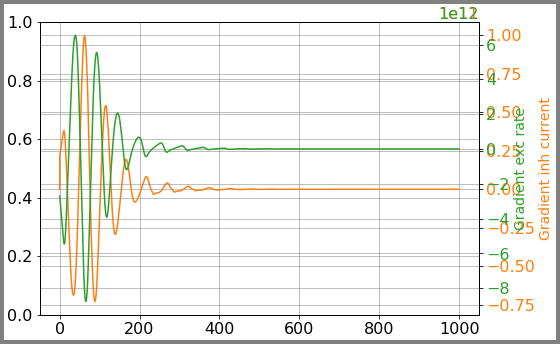

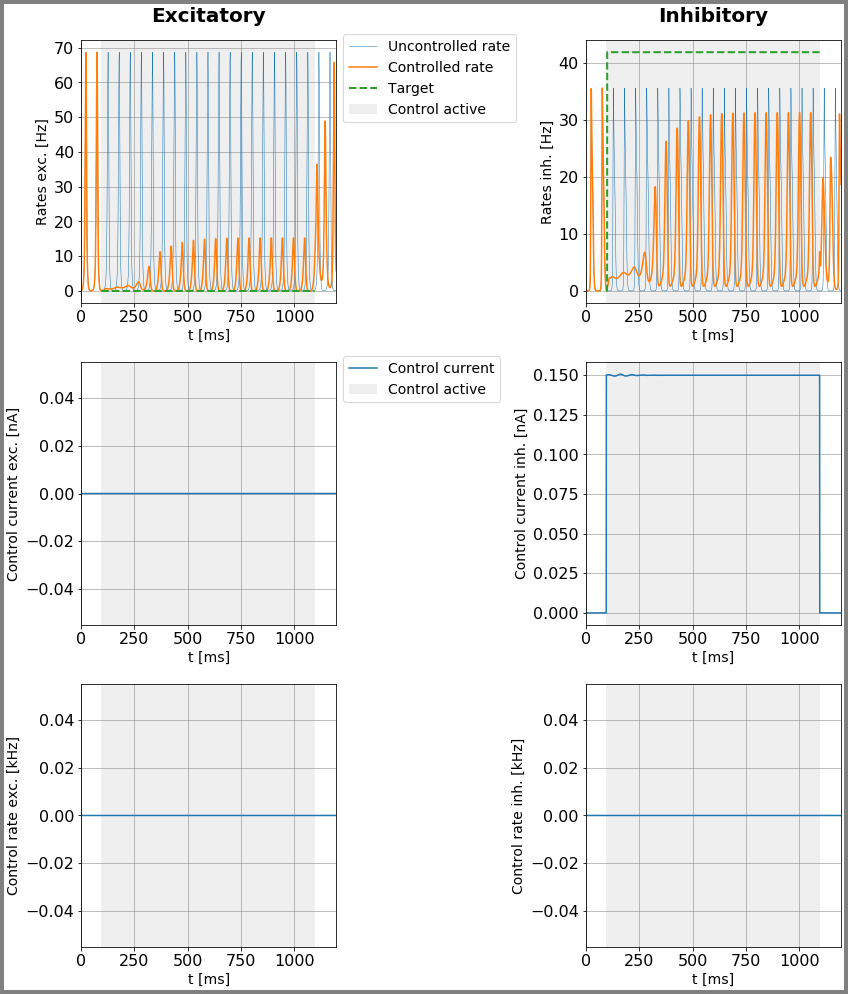

In [33]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = 0.75
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  0.00017932956436493558
RUN  1 , total integrated cost =  0.00015051837964231312
RUN  2 , total integrated cost =  0.00015051778263427517
RUN  3 , total integrated cost =  0.00015051778263274883
RUN  4 , total integrated cost =  0.00015051778263274816
RUN  5 , total integrated cost =  0.00015051778263274805
RUN  6 , total integrated cost =  0.00015051778263274764
RUN  7 , total integrated cost =  0.00015051778263274742
RUN  8 , total integrated cost =  0.0001505177826327472


ERROR:root:Problem in initial value trasfer


RUN  9 , total integrated cost =  0.0001505177826327472
Control only changes marginally.
RUN  9 , total integrated cost =  0.0001505177826327472
Improved over  9  iterations by  16.06638695310518  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716


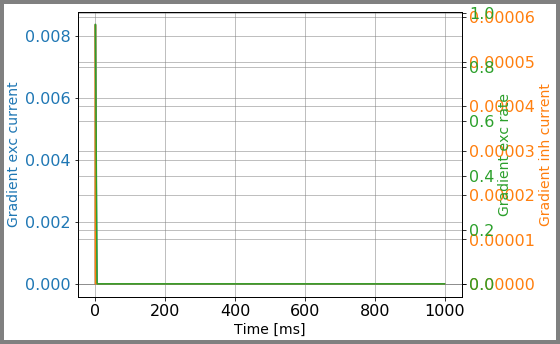

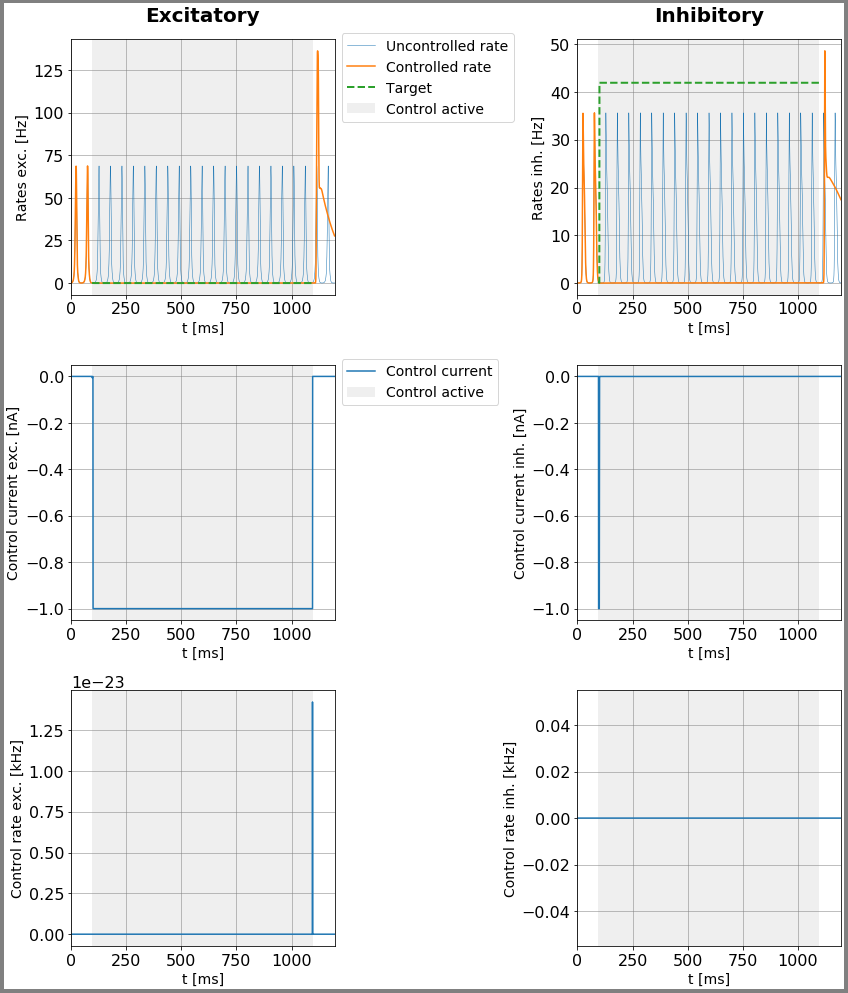

In [36]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -5.
#control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  36722.66500300185
RUN  1 , total integrated cost =  35867.60018372005
RUN  2 , total integrated cost =  32622.61472844767
RUN  3 , total integrated cost =  32622.614728447654
RUN  4 , total integrated cost =  32622.614728447625


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  32622.614728447625
Control only changes marginally.
RUN  5 , total integrated cost =  32622.614728447625
Improved over  5  iterations by  11.16490394751871  percent.
Problem in initial value trasfer:  Vmean_exc -65.54410146579905 -65.5633639663716
Problem in initial value trasfer:  Vmean_exc -64.95416501482376 -64.92590250803327


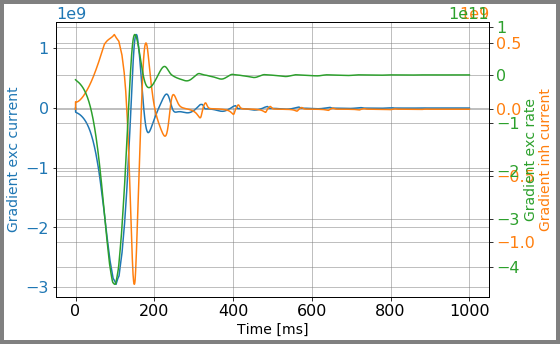

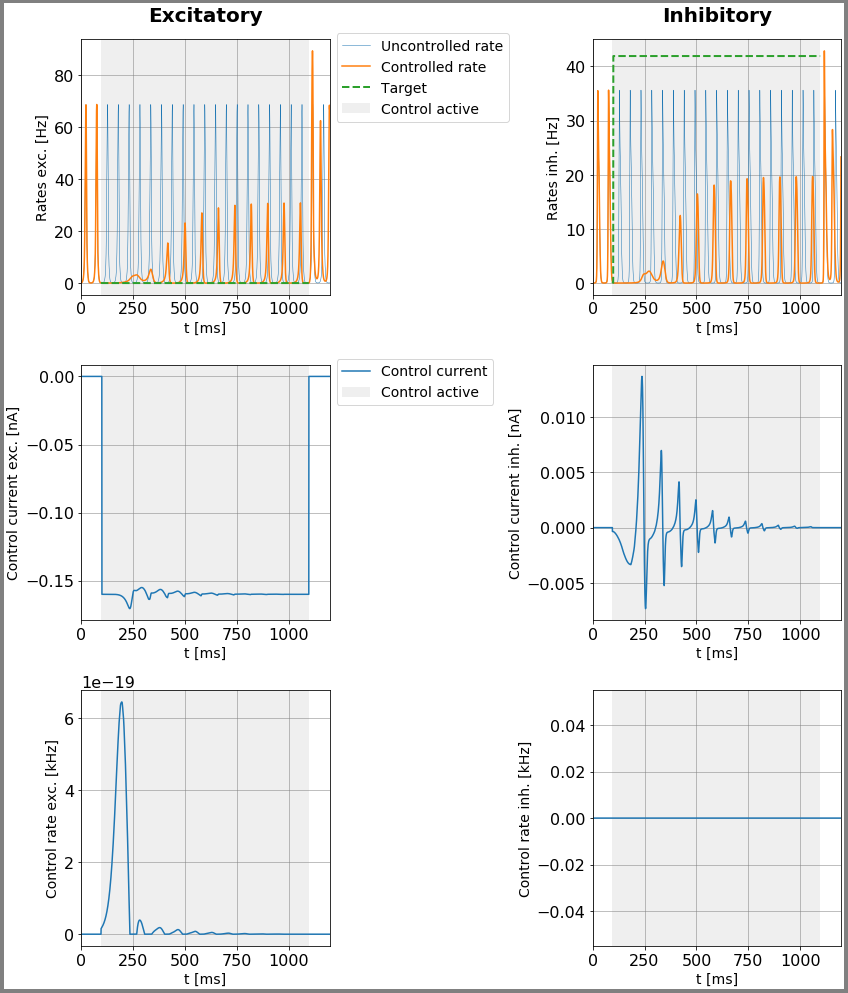

In [37]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = -0.8
#control0[0,1,:] = 5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )